In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.datasets import mnist

In [2]:
(x_train,y_train),(x_test,y_test) = mnist.load_data() 

In [3]:
print("Shape of X Train",x_train.shape)
print("Shape of X Test",x_test.shape)
print("Shape of Y Train",y_train.shape)
print("Shape of Y Test",y_test.shape)

Shape of X Train (60000, 28, 28)
Shape of X Test (10000, 28, 28)
Shape of Y Train (60000,)
Shape of Y Test (10000,)


In [4]:
x_train = x_train/255.0
x_test = x_test/255.0

In [5]:
print("Shape of X Train",x_train.shape)
print("Shape of X Test",x_test.shape)
print("Shape of Y Train",y_train.shape)
print("Shape of Y Test",y_test.shape)

Shape of X Train (60000, 28, 28)
Shape of X Test (10000, 28, 28)
Shape of Y Train (60000,)
Shape of Y Test (10000,)


In [6]:
x_train = x_train.reshape(-1, 28,28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
print("Shape of X Train",x_train.shape)
print("Shape of X Test",x_test.shape)

Shape of X Train (60000, 28, 28, 1)
Shape of X Test (10000, 28, 28, 1)


In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.1,0.1)
])

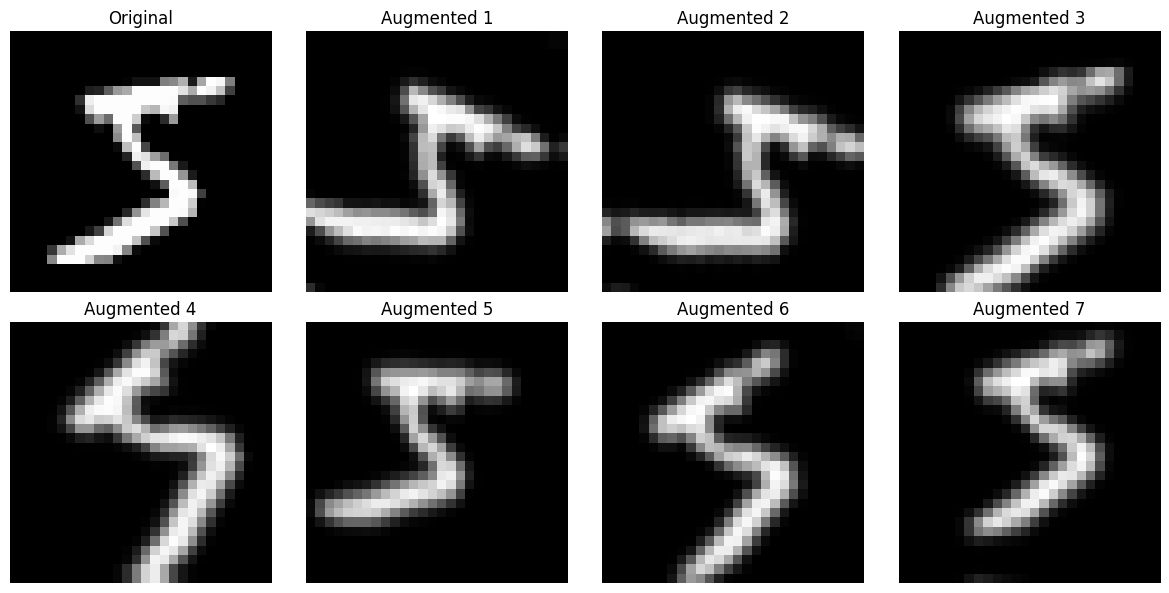

In [8]:
plt.figure(figsize=(12, 6))

# Select one training image
image = x_train[0]

# Original image
plt.subplot(2, 4, 1)
plt.imshow(image.squeeze(), cmap="gray")
plt.title("Original")
plt.axis("off")

# Augmented images
for i in range(1, 8):
    augmented_image = data_augmentation(
        tf.expand_dims(image, axis=0),
        training=True
    )

    plt.subplot(2, 4, i + 1)
    plt.imshow(augmented_image[0].numpy().squeeze(), cmap="gray")
    plt.title(f"Augmented {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
model = keras.Sequential([
    
    data_augmentation,
    
    keras.layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    
    keras.layers.MaxPooling2D((2, 2)),
    
    keras.layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),
    
    keras.layers.MaxPooling2D((2, 2)),
    
    keras.layers.Flatten(),
    
    keras.layers.Dense(
        128,
        activation='relu'
    ),
    
    keras.layers.Dropout(0.3),
    
    keras.layers.Dense(
        10,
        activation='softmax'
    )
])

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (1, 28, 28, 1)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (1, 26, 26, 32)             │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (1, 13, 13, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (1, 11, 11, 64)             │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (1, 5, 5, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (1, 1600)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (1, 128)                    │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (1, 128)                    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (1, 10)                     │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    x_train,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32
)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.8276 - loss: 0.5337 - val_accuracy: 0.9805 - val_loss: 0.0673
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - accuracy: 0.9306 - loss: 0.2260 - val_accuracy: 0.9837 - val_loss: 0.0558
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.9471 - loss: 0.1735 - val_accuracy: 0.9843 - val_loss: 0.0541
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 33s 20ms/step - accuracy: 0.9562 - loss: 0.1413 - val_accuracy: 0.9880 - val_loss: 0.0443
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.9626 - loss: 0.1232 - val_accuracy: 0.9847 - val_loss: 0.0581
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.9657 - loss: 0.1127 - val_accuracy: 0.9898 - val_loss: 0.0391
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.9678 - loss: 0.1057 - val_accuracy: 0.9885 - val_loss: 0.0489
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.9710 -

In [18]:
test_loss, test_accuracy = model.evaluate(x_test,y_test)
print("Test Accuracy: ",test_accuracy)
print("Test Loss: ", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9908 - loss: 0.0358
Test Accuracy:  0.9908000230789185
Test Loss:  0.035772476345300674


In [21]:
predictions = model.predict(x_test)
print("Predictions: ",predictions)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Predictions:  [[2.0259112e-16 4.0158272e-07 6.1865563e-10 ... 9.9999964e-01
  9.2137788e-13 8.1280571e-10]
 [1.2455101e-12 1.3183711e-09 1.0000000e+00 ... 2.9434530e-13
  6.0021449e-10 1.2802351e-15]
 [1.7369341e-12 9.9999976e-01 7.7970219e-10 ... 2.7496947e-07
  2.6318838e-09 4.4881259e-09]
 ...
 [9.7346386e-18 2.5236627e-10 3.3620062e-11 ... 6.2936822e-11
  7.4601543e-09 2.7871565e-09]
 [1.0500383e-18 4.7969521e-17 1.9760103e-15 ... 4.6409752e-21
  1.8056114e-10 3.6364112e-10]
 [1.4970090e-07 1.7497265e-15 2.1564874e-14 ... 3.0393637e-23
  1.3254196e-10 5.2873715e-15]]


In [22]:
predicted_labels = np.argmax(predictions, axis=1)
print("Prediction: ",predicted_labels[:10])
print("Actual: ",y_test[:10])

Prediction:  [7 2 1 0 4 1 4 9 5 9]
Actual:  [7 2 1 0 4 1 4 9 5 9]


In [26]:
print("Validation Accuracy",max(history.history["val_accuracy"]))
print("Training Accuracy",max(history.history["accuracy"]))
print("Test Accuracy",test_accuracy)

Validation Accuracy 0.9921666383743286
Training Accuracy 0.9806666374206543
Test Accuracy 0.9908000230789185


In [27]:
print("Validation Loss",max(history.history["val_loss"]))
print("Training Loss",max(history.history["loss"]))
print("Test Loss",test_loss)

Validation Loss 0.0673055350780487
Training Loss 0.5337146520614624
Test Loss 0.035772476345300674
